In [5]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import math
import numpy as np
import random
from Cell2D import Cell2D
import requests

In [6]:
file_id = "1bEpF3iwAnaorj-Xl870gB62uqro5arQ3"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"
response = requests.get(url)

with open("airplane_data.xlsx", "wb") as f:
    f.write(response.content)

In [7]:
# method to read data from excel file
def read_plane_data(file_name):
    df_planes = pd.read_excel(file_name)
    return df_planes

df = read_plane_data('airplane_data.xlsx')

print('Here are your plane choices:')
print(df['aircraft_type'])

Here are your plane choices:
0                        A220-300
1              Bombardier CRJ-900
2                Beechcraft 1900D
3            Boeing 737-300 (733)
4      Airbus A319 (319) Layout 1
5    Embraer E-175 (E75) Layout 1
6           Airbus A320-200 (320)
7         Boeing 737-700 Layout 2
8                ATR 72-600 (ATR)
9            Boeing 717-200 (717)
Name: aircraft_type, dtype: object


In [13]:
plane_choice = input("Input the number corresponding to the plane you'd like to simulate:")    

Input the number corresponding to the plane you'd like to simulate: 5


In [15]:
plane_type = df.loc[int(plane_choice)].at['aircraft_type']
print('You selected:', plane_type)

You selected: Embraer E-175 (E75) Layout 1


In [29]:
def seat_params_info(df, plane_num):
    """Function to gather information from table regarding seat dimensions and return a list of tuples."""
    seat_width_economy = df.loc[int(plane_num)].at['seat width - economy']
    seat_pitch_economy = df.loc[int(plane_num)].at['seat depth - economy']
    seat_param_economy = seat_width_economy, seat_pitch_economy

    seat_width_business = df.loc[int(plane_num)].at['seat width - business']
    seat_pitch_business = df.loc[int(plane_num)].at['seat depth - business']
    seat_param_business = seat_width_business, seat_pitch_business

    seat_width_1stclass = df.loc[int(plane_num)].at['seat width - first class']
    seat_pitch_1stclass = df.loc[int(plane_num)].at['seat depth - first class']
    seat_param_1stclass = seat_width_1stclass, seat_pitch_1stclass

    seat_params = [seat_param_economy, seat_param_business, seat_param_1stclass]

    return seat_params

In [27]:
def num_of_seats_info(df, plane_num):
    """Function to gather information from table regarding number of seats and return a tuple."""
    econ = df.at[int(plane_num), "total seats - economy"]
    bus = df.at[int(plane_num), "total seats - business"]
    first = df.at[int(plane_num), "total seats - first class"]
    
    num_of_seats = econ, bus, first

    return num_of_seats

In [25]:
def seat_arrange_info(df, plane_num):
    """Function to gather information from table regarding seat arrangement and return a list."""
    seat_arrange_econ = df.loc[int(plane_num)].at['seat arrangement - economy']

    seat_arrange_bus = df.loc[int(plane_num)].at['seat arrangement - business']
    
    seat_arrange_1st = df.loc[int(plane_num)].at['seat arrangement - first class']
    
    seat_arrange = [seat_arrange_econ, seat_arrange_bus, seat_arrange_1st]

    return seat_arrange

In [31]:
class Seat:
    def __init__(self, seat_label, class_type, coords, side_of_plane, width):
        self.seat_label = seat_label
        self.letter = seat_label[-1]
        self.row = int(seat_label[:-1])
        self.class_type = class_type
        self.occupied = False
        self.x_coord, self.y_coord = coords
        self.depth = 18
        self.width = width
        self.side_of_plane = side_of_plane

In [33]:
class Plane:
    def __init__(self, seat_params, num_of_seats, seat_arrange):
        """
        Initialize seat dimensions, number of seats, and arrangement for each class.
        """
        self.seat_param_economy = seat_params[0]
        self.seat_param_business = seat_params[1]
        self.seat_param_firstclass = seat_params[2]

        self.num_of_seats_economy = num_of_seats[0]
        self.num_of_seats_business = num_of_seats[1]
        self.num_of_seats_firstclass = num_of_seats[2]

        self.seat_arrange_economy = seat_arrange[0]
        self.seat_arrange_business = seat_arrange[1]
        self.seat_arrange_firstclass = seat_arrange[2]

        self.seats = []  # List to store all Seat objects

        self.setup_plane_geometry()  # Set up y-coordinates and layout
        self.generate_all_seats()    # Generate all seats across classes

    def generate_seat_labels(self, starting_row, num_of_rows, seats_per_row):
        """Generate seat labels like 1A, 1B... in reverse order"""
        seat_labels = []
        for row in range(starting_row, num_of_rows + starting_row):
            for seat in range(seats_per_row):
                seat_letter = chr(64 + seats_per_row - seat)  # Letters from right to left
                seat_labels.append(f"{row}{seat_letter}")
        return seat_labels[::-1]  # Reverse to match drawing order

    def generate_seats(self, seat_type, starting_row, class_type):
        """Generate Seat objects with layout and positions for a section of the plane."""
        seats_per_col, seats_per_row, num_of_rows, seat_width, leg_room, aisle_gap, start_y = seat_type
        leg_room -= seat_width  # Calculate extra leg space
        seat_depth = 18    # Fixed seat depth

        seat_labels = self.generate_seat_labels(starting_row, num_of_rows, seats_per_row)
        label_index = 0

        y = start_y
        padding = 1
        
        for row in range(num_of_rows):
            x = 0
            
            # Left side seats
            for seat in range(seats_per_col[0]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "left", seat_width))
                label_index += 1
                x += seat_depth + padding

            # Aisle space
            x += aisle_gap

            # Right side seats
            for seat in range(seats_per_col[2]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "right", seat_width))
                label_index += 1
                x += seat_depth + padding
            
            y += leg_room + seat_width  # Move down for next row

    def generate_all_seats(self):
        """Reset and generate all seats for all classes."""
        self.seats = []
        y_offset = 0
        starting_row = 1
        reference_params = None  # For aisle alignment
    
        class_sections = [
            ("economy", self.num_of_seats_economy, self.seat_param_economy, self.seat_arrange_economy),
            ("business", self.num_of_seats_business, self.seat_param_business, self.seat_arrange_business),
            ("first", self.num_of_seats_firstclass, self.seat_param_firstclass, self.seat_arrange_firstclass)
        ]
    
        for class_type, num_seats, seat_param, seat_arrange in class_sections:
            # Determine starting row number based on class
            if class_type == "economy":
                starting_row = self.first_class_rows + self.business_class_rows + 1
            elif class_type == "business":
                starting_row = self.first_class_rows + 1
            elif class_type == "first":
                starting_row = 1

            if num_seats > 0:
                draw_inputs = self.get_draw_inputs(seat_param, seat_arrange, num_seats, y_offset, reference_params)
                self.generate_seats(draw_inputs, starting_row, class_type)

                num_rows = draw_inputs[2]
                seat_pitch = draw_inputs[4]
                y_offset += num_rows * seat_pitch  # Update y offset for next class
                starting_row += num_rows

                if not reference_params:
                    reference_params = draw_inputs  # Save reference for alignment

    def find_parameters(self, seat_dims, seat_arrangement, num_of_seats):
        """
        Convert seat config into layout information.
        Returns tuple of seats_per_col, seats_per_row, num_rows, seat_width, leg_room
        """
        seats_per_col = seat_arrangement.split(' ')
        for i, num in enumerate(seats_per_col):
            seats_per_col[i] = int(num)

        dummy_var = seats_per_col[len(seats_per_col)//2]
        seats_per_col[len(seats_per_col)//2] = 0
        seats_per_col.append(dummy_var)

        seats_in_row = sum(seats_per_col)
        num_of_rows = math.ceil(num_of_seats/seats_in_row)

        seat_width = seat_dims[0]
        leg_room = seat_dims[1] 

        return seats_per_col, seats_in_row, num_of_rows, seat_width, leg_room

    def setup_plane_geometry(self):
        """Set class-wise layout and y-offsets"""
        current_y = 0

        # First Class
        if self.num_of_seats_firstclass > 0:
            first_class = self.find_parameters(self.seat_param_firstclass, self.seat_arrange_firstclass, self.num_of_seats_firstclass)
            self.first_class_rows = first_class[2]
            self.first_pitch = first_class[4]
            self.first_class_start_y = current_y
            current_y += self.first_class_rows * self.first_pitch
        else:
            self.first_class_rows = 0
            self.first_pitch = 0
            self.first_class_start_y = 0

        # Business Class
        if self.num_of_seats_business > 0:
            business_class = self.find_parameters(self.seat_param_business, self.seat_arrange_business, self.num_of_seats_business)
            self.business_class_rows = business_class[2]
            self.business_pitch = business_class[4]
            self.business_class_start_y = current_y
            current_y += self.business_class_rows * self.business_pitch
        else:
            self.business_class_rows = 0
            self.business_pitch = 0
            self.business_class_start_y = current_y

        # Economy Class
        economy_class = self.find_parameters(self.seat_param_economy, self.seat_arrange_economy, self.num_of_seats_economy)
        self.economy_seats_in_row = economy_class[1]
        self.economy_rows = economy_class[2]
        self.economy_pitch = economy_class[4]
        self.economy_class_start_y = current_y
        current_y += self.economy_rows * self.economy_pitch

        self.plane_width = economy_class[1] * (18 + 1) + 17  # Estimate full width
        self.plane_length = current_y  # Final total vertical length

    def get_draw_inputs(self, seat_param, seat_arrange, num_of_seats, start_y, reference_params=None, padding=1):
        """Compute drawing parameters for a section and align aisles if needed"""
        params = self.find_parameters(seat_param, seat_arrange, num_of_seats)

        class_width = params[1] * (18 + padding) 
        aisle_gap = self.plane_width - class_width
        return params + (aisle_gap, start_y)

    def draw_seats(self, ax):
        """Draw each seat rectangle on matplotlib axis"""
        self.seats = sorted(self.seats, key=lambda seat: (seat.row, seat.letter))
        for seat in self.seats:
            x, y = seat.x_coord, seat.y_coord
            rect = patches.Rectangle((x, y), seat.depth, seat.width, edgecolor='black', facecolor='lightskyblue')
            ax.add_patch(rect)
            ax.text(x + seat.depth / 2, y + seat.width / 2, seat.seat_label, ha='center', va='center', fontsize=6)

    def draw(self):
        """Initialize and return the figure with drawn seats"""
        fig, ax = plt.subplots()
        self.draw_seats(ax)
        return fig, ax

In [35]:
class Passenger:
    def __init__(self, seat):
        self.seat = seat
        self.current_row_location = 0 # y-position in aisle
        self.x_pos = 0
        self.y_pos = 0
        self.speed = None                              # default — will be updated to match seat pitch
        self.status = "not seated"
        self.bag = self.has_bag()

    def has_bag(self):
        # https://www.theatlantic.com/technology/archive/2024/02/airplane-carry-on-luggage-crisis-conspiracy/677452/
        # approximately 80% of people bring a carry on bag
        return random.random() < 0.8

In [ ]:

    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
            
                if prev_position is None:  # No one in front
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False
    
                if can_move:
                    # change speed based on location in plane so move one seat forward each time
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
                    
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row and passenger.status == "not seated":
                passenger.speed = 0
                passenger.status = "unloading"

            elif passenger.current_row_location == passenger.seat.row and passenger.status == "unloading":
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
                    
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
            
                passenger.status = "seated"
                passenger.seat.occupied = True
                # ADD!!!! check if other people are in the row and have to get out for you to get to your seat


In [89]:
class PlaneBoarding(Cell2D):
    def __init__(self, num_of_passengers, plane, boarding_method, constructor=Passenger):
        self.plane = plane
        self.passengers = []
        num_of_passengers = int(num_of_passengers)
        
        if self.plane.num_of_seats_firstclass > 0:
            largest_pitch = self.plane.first_pitch
        elif self.plane.num_of_seats_business > 0:
            largest_pitch = self.plane.business_pitch
        else:
            largest_pitch = self.plane.economy_pitch
        
        booked_seats = random.sample([seat for seat in self.plane.seats], num_of_passengers)
        
        # Create start positions just outside the plane
        self.passengers = [constructor(seat) for seat in booked_seats]

        # make method to call boarding/seating method here     
        self.passengers = self.select_boarding_method(boarding_method)

        for i, passenger in enumerate(self.passengers):
            passenger.current_row_location = -i
            passenger.x_pos = self.plane.plane_width/2
            passenger.y_pos = self.plane.plane_length + (i+1) * largest_pitch
    
    def find_coords(self, passengers):
        x_coords = np.array([(passenger.x_pos) for passenger in passengers])
        y_coords = np.array([(passenger.y_pos) for passenger in passengers])
        
        return x_coords, y_coords

    def select_boarding_method(self, boarding_method_num):
        # need first class/business class passengers at top of list so they get seated first
        priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type in ["business", "first"]]
        
        # make list of all passengers not in first class - pass this to other functions to sort/put in specific order for boarding
        non_priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type == "economy"]

        # TODO: finish this method with group during meeting!!!
        if boarding_method_num == 0:
            # call random method
            return priority_passengers + random_boarding(non_priority_passengers)
        #elif boarding_method_num == 1:
            # call boarding method 1's method
            
        #elif boarding_method_num == 2:
            # call boarding method 2's method
            
        #elif boarding_method_num == 3:
            # call boarding method 3's method
        else:
            return priority_passengers + non_priority_passengers

    def random_boarding(self, econ_passengers):
        return random.shuffle(econ_passengers)
        
    def step(self):
        positions_before = [p.current_row_location for p in self.passengers]
    
        for i, passenger in enumerate(self.passengers):
            previous_position = positions_before[i - 1] if i > 0 else None
            previous_status = self.passengers[i - 1].status if i > 0 else None
            previous_speed = self.passengers[i - 1].speed if i > 0 else None
    
            self.move(passenger, previous_position, previous_status, previous_speed)

    def all_passengers_seated(self):
        return all(passenger.status == "seated" for passenger in self.passengers)
    
    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
    
                if prev_position is None:  # No one in front
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False  # Wait behind someone unloading their bag
    
                if can_move:
                    # Determine pitch based on section
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
    
                    # Move forward one row
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row:
                # Stop to unload bag
                passenger.speed = 0
                passenger.status = "unloading"
    
                # Add delay counter if not already set
                if not hasattr(passenger, "bag_delay"):
                    passenger.bag_delay = 2 if passenger.has_bag else 0  # Delay only if they have a bag
    
        elif passenger.status == "unloading":
            if passenger.bag_delay > 0:
                passenger.bag_delay -= 1  # Wait while unloading
            else:
                # Now move to seat and be seated
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                passenger.status = "seated"
                passenger.seat.occupied = True
        
    def draw(self):
        fig, ax = self.plane.draw()
        x_coords, y_coords = self.find_coords(self.passengers)

        for passenger, x, y in zip(self.passengers, x_coords, y_coords):
            person = patches.Circle((x, y), radius=6, edgecolor='black', facecolor='salmon')
            ax.add_patch(person)

            if passenger.bag:
                bag = patches.Rectangle((x + 5, y-2), width=2, height=4, color='brown')
                ax.add_patch(bag)

        fig.set_size_inches((self.plane.plane_width + 5) * 0.025, (self.plane.plane_length) * 0.025)

        ax.set_xlim(0, self.plane.plane_width + 5)
        ax.set_ylim(0, self.plane.plane_length)  
        ax.set_aspect('equal')
        ax.set_autoscale_on(False)

        plt.axis('equal')
        plt.axis('off')
        plt.show()

In [41]:
plane = Plane(seat_params_info(df, plane_choice), num_of_seats_info(df, plane_choice), seat_arrange_info(df, plane_choice))

print(f"There are {len(plane.seats)} seats on the plane.")

There are 100 seats on the plane.


In [121]:
num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

while int(num_of_passengers) > len(plane.seats):
    print(f"Please input a number less than or equal to {len(plane.seats)}.")
    num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

How many passengers would you like to simulate (aka. board the plane)? 2


In [45]:
print('Here are your boarding method choices:')
print('0\t\tRandom Method\n1\t\tINPUT METHOD 1 HERE\n2\t\tINPUT METHOD 2 HERE\n3\t\tINPUT METHOD 3 HERE\n4\t\tINPUT METHOD 4 HERE')

Here are your boarding method choices:
0		Random Method
1		INPUT METHOD 1 HERE
2		INPUT METHOD 2 HERE
3		INPUT METHOD 3 HERE
4		INPUT METHOD 4 HERE


In [47]:
boarding_choice = input("Input the number corresponding to the boarding method you'd like to simulate:")

Input the number corresponding to the boarding method you'd like to simulate: 0


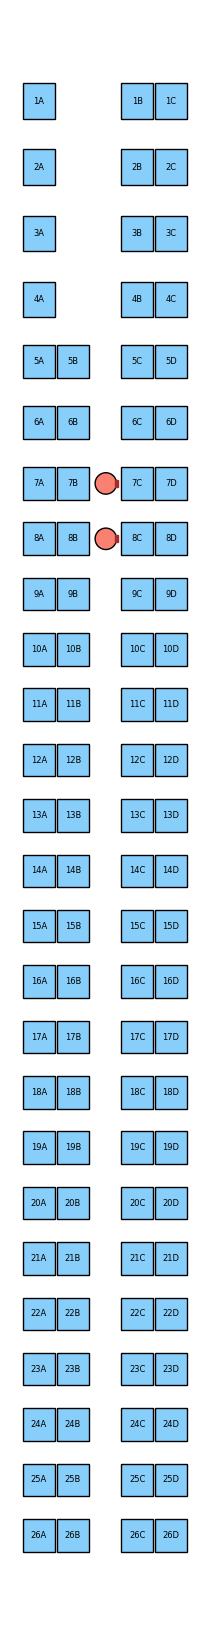

In [123]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
plane_boarding.animate(frames = 10, interval = 1)

In [119]:
def run_simulation(boarding):
    steps = 0
    while not boarding.all_passengers_seated():
        boarding.step()
        steps += 1

In [117]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
run_simulation(plane_boarding)

✅ All passengers seated in 34 steps.
